# AG-HYPOPT · Trial 32

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirty-one trials are registered; cell 2 reports `phase = trials` (31/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074), with **trial_30** (0.1083) a close second. Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- best (all 0 div): trial_21 0.1074 (0.138), trial_30 0.1083 (0.134), trial_22 0.1095 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_31 0.1106 (0.131), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138), trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127.
- worse: trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (0.194), trial_06 = trial_11 0.1188.
- diverging at 1nW T05 (near-optimum travel): trial_29 0.1331, trial_26 0.1368, trial_28 0.1370. Other diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418, trial_02 0.1449.

State of play: single optimum spike at travel ~0.137-0.138 with balanced gamma knobs. When a run survives the 1nW T05 cell it delivers ~0.107-0.113 (six runs below 0.111); otherwise the diverged cell costs ~0.02-0.07. The schedule family is converged; the divergence is the dominant remaining effect. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_32'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (31/5 trials)
ID |     ei | params
 1 | 2.5418 | {"gamma_anneal": 0.48269219140157343, "lr_gamma": 0.4651129145440586, "lr_mu": 0.14026012604932322, "mu_anneal": 0.3530501718519793}
 2 | 3.8050 | {"gamma_anneal": 0.5010726716141943, "lr_gamma": 0.45784981924950113, "lr_mu": 0.16397949078190685, "mu_anneal": 0.3504389617180524}
 3 | 1.5748 | {"gamma_anneal": 0.49075316563557825, "lr_gamma": 0.2715236511391681, "lr_mu": 0.15916665627759624, "mu_anneal": 0.4592070354143448}
 4 | 3.3719 | {"gamma_anneal": 0.5108488997540632, "lr_gamma": 0.4869859787895707, "lr_mu": 0.16266274372046438, "mu_anneal": 0.3518160879939118}
 5 | 0.4022 | {"gamma_anneal": 0.8320771550027124, "lr_gamma": 0.42338790235198437, "lr_mu": 0.15553327789001758, "mu_anneal": 0.3592370282166862}
 6 | 3.7464 | {"gamma_anneal": 0.5013770674983857, "lr_gamma": 0.42546803242716563, "lr_mu": 0.15883107835800278, "mu_anneal": 0.3477426647733562}
 7 | 1.3673 | {"gamma_anneal": 0.4426955541495495, "lr_gamma": 0.473

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (31 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 8: **ei 3.84** — `lr_mu=0.1656`, `mu_anneal=0.3487` (travel **0.137**), `lr_gamma=0.4173`, `gamma_anneal=0.5221`.
- candidate 2: ei 3.81 — `lr_mu=0.1640`, `mu_anneal=0.3504` (travel 0.135), `lr_gamma=0.4578`, `gamma_anneal=0.5011`.
- candidate 6: ei 3.75 — `lr_mu=0.1588`, `mu_anneal=0.3477` (travel 0.131), `lr_gamma=0.4255`, `gamma_anneal=0.5014`.
- candidate 4: ei 3.37 — `lr_mu=0.1627`, `mu_anneal=0.3518` (travel 0.134), `lr_gamma=0.4870`, `gamma_anneal=0.5108`.
- candidate 1: ei 2.54 — `lr_mu=0.1403`, `mu_anneal=0.3531` (travel 0.115), `lr_gamma=0.4651`.

Candidate 8 has the highest ei and sits exactly at the optimum (travel 0.137, matching trial_22; gamma knobs `lr_gamma=0.4173`/`gamma_anneal=0.5221` in the proven-safe range). Candidates 2 and 6 are the same region at lower ei, and candidate 8 is simply the maximum-ei optimum point. Given the region is fully characterised and only the 1nW T05 divergence adds variance, drawing the best-point resample again is the natural move - it either confirms another ~0.108 (if it survives) or adds another divergence data point.

I choose candidate 8 (8 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5220754356321338, 'lr_gamma': 0.41733921515603717, 'lr_mu': 0.1656109291081796, 'mu_anneal': 0.3487142119036593}
Running  1nW Trans05 ... 

μ 9.39 -> 10.30 | γ 8.5 -> 4.47 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 46.67 | γ 8.5 -> 6.18 | NLL 5.64


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 78.93 | γ 14.1 -> 14.35 | NLL 3.32


Running 3nW Trans100 ... 

μ 175.71 -> 109.85 | γ 14.1 -> 14.07 | NLL 3.39



Total: 8.9 min


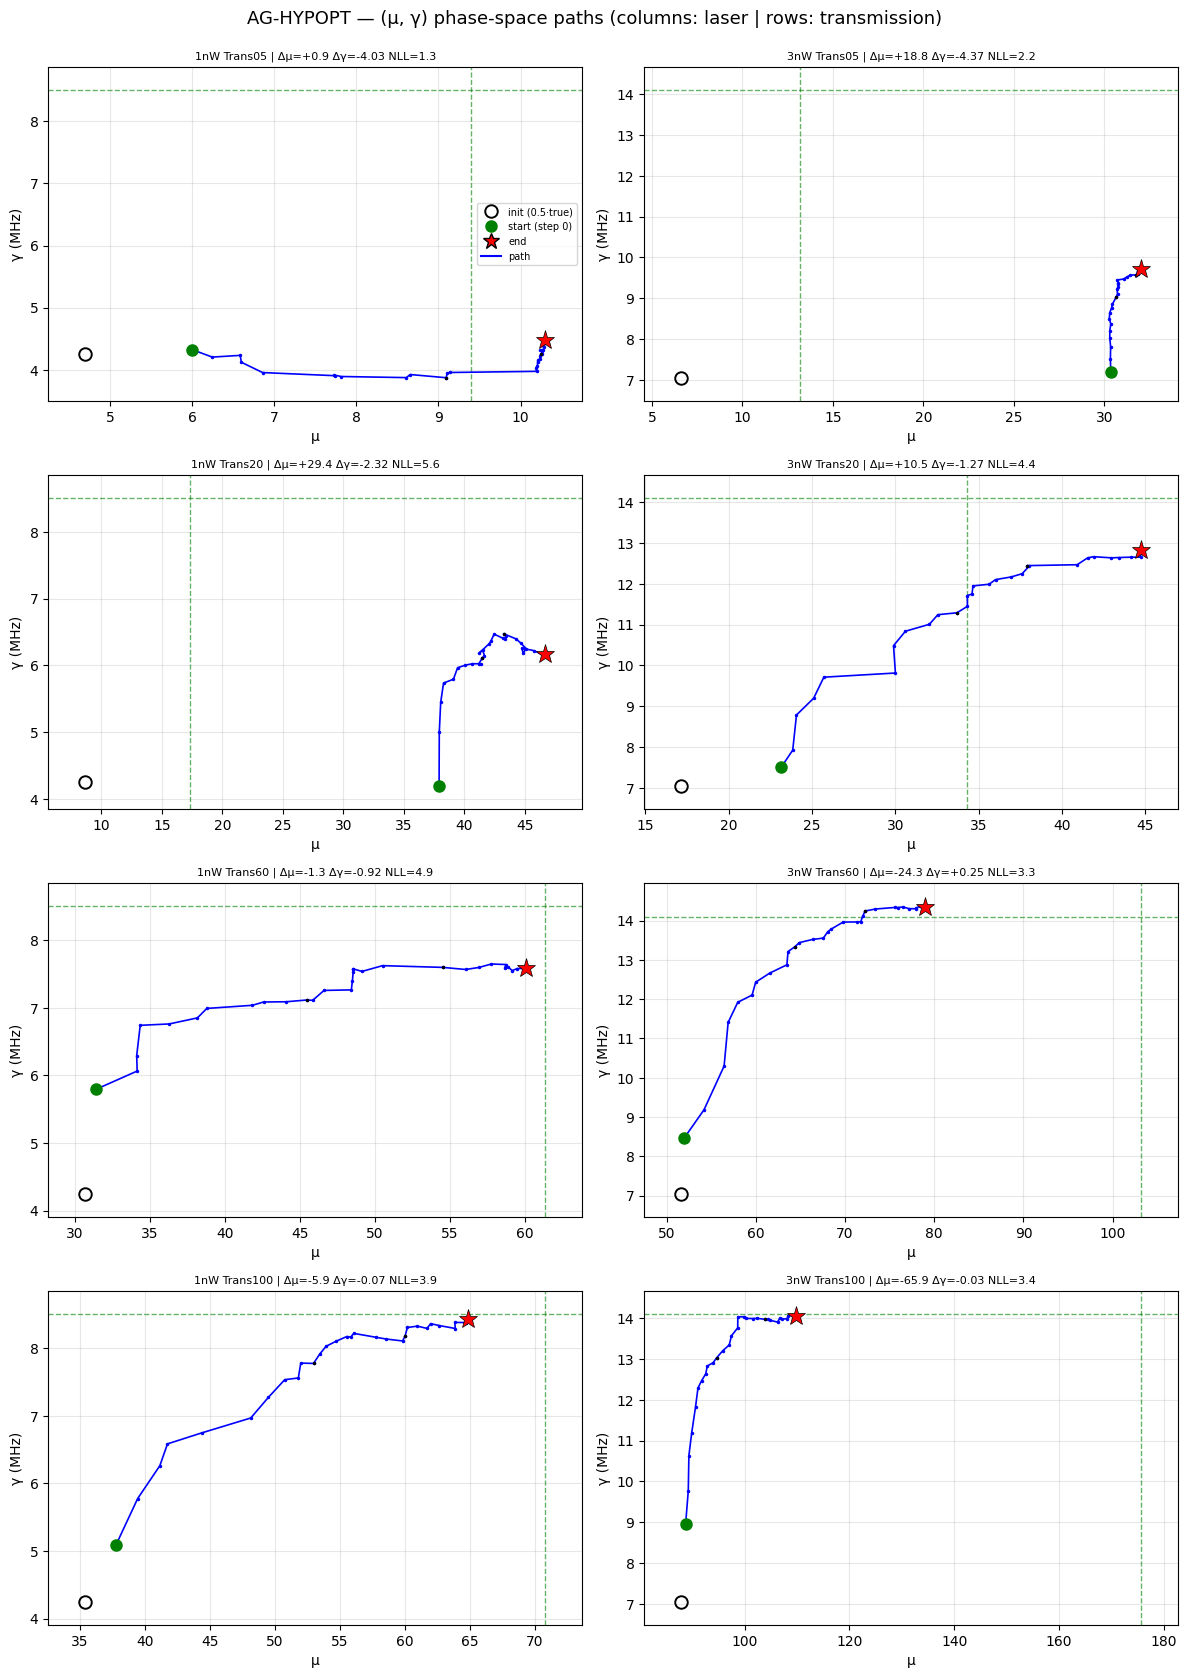

trial finished in 8.9 min
objective = 0.1097 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.30    +9.7 |     8.50    4.47   -47.4
1nW Trans20       17.32   46.67  +169.5 |     8.50    6.18   -27.3
1nW Trans60       61.37   60.10    -2.1 |     8.50    7.58   -10.8
1nW Trans100       70.82   64.90    -8.4 |     8.50    8.43    -0.9
3nW Trans05       13.20   32.04  +142.7 |    14.10    9.73   -31.0
3nW Trans20       34.28   44.76   +30.6 |    14.10   12.83    -9.0
3nW Trans60      103.20   78.93   -23.5 |    14.10   14.35    +1.8
3nW Trans100      175.71  109.85   -37.5 |    14.10   14.07    -0.2

weighted objective (T-graded, cap=1.0) = 0.1097 | diverged cells: 0
μ: RMSE 28.043 (rel 80.7%, bias -4.718) | γ: RMSE 2.325 (rel 22.8%, bias -1.595)


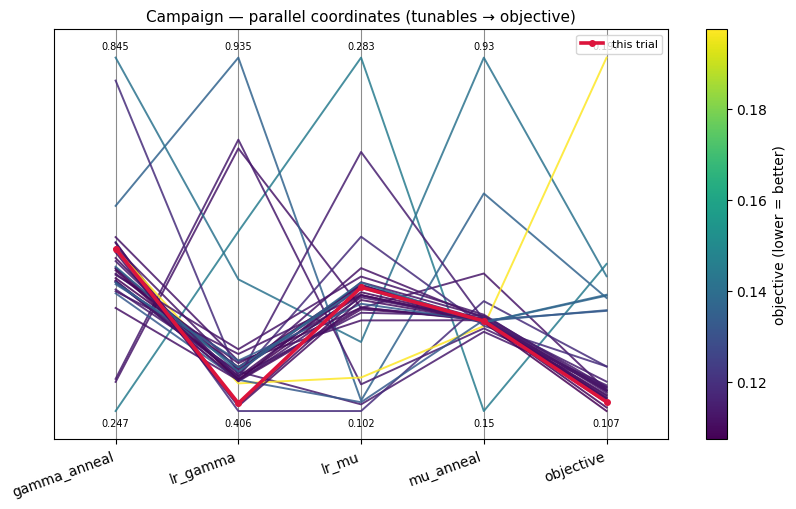

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 32 ran the highest-EI candidate (candidate 8, ei=3.84): `lr_mu=0.1656`, `mu_anneal=0.3487` (effective mu travel 0.137), `lr_gamma=0.4173`, `gamma_anneal=0.5221`. It completed in 8.9 min with objective **0.1097 +/- 0.0825** and **0 diverged cells** — fourth-best. Ranking: trial_21 0.1074 < trial_30 0.1083 < trial_22 0.1095 < **trial_32 0.1097** < trial_08 0.1099 < trial_15 0.1103 < trial_31 0.1106 < ...

Aggregate accuracy: **mu rel-RMSE 80.7%** (RMSE 28.04, bias -4.72); **gamma rel-RMSE 22.8%** (RMSE 2.33, bias -1.60).

Per-cell relative errors:
- **mu:** 1nW T05 +9.7%, T20 +169.5%, T60 -2.1%, T100 -8.4% | 3nW T05 +142.7%, T20 +30.6%, T60 -23.5%, T100 -37.5%.
- **gamma:** 1nW T05 -47.4%, T20 -27.3%, T60 -10.8%, T100 -0.9% | 3nW T05 -31.0%, T20 -9.0%, T60 +1.8%, T100 -0.2%.

A survival at the exact optimum (travel 0.137), divergence-free, landing at 0.1097 — fourth-best, right in the tight band the region produces. Nothing new: the usual mid-T overshoots, the usual 3nW high-T undershoot, clean high-T gamma. With this run the optimum region has **seven** surviving samples below 0.111 (0.1074, 0.1083, 0.1095, 0.1097, 0.1099, 0.1103, 0.1106), so the achievable level is very tightly reproducible at ~0.108-0.110 whenever the 1nW T05 cell survives. trial_21 (0.1074) remains the best.

**Summary:** Trial 32 (lr_mu=0.1656, mu_anneal=0.3487, lr_gamma=0.4173, gamma_anneal=0.5221): objective 0.1097 +/- 0.0825 with 0 diverged cells; another survival at the optimum (travel 0.137) landed fourth-best, so the region's typical level stays ~0.108-0.110 and trial_21 (0.1074) remains best.
**Key insight:** The optimum region now has seven surviving samples below 0.111 (0.1074-0.1106), so the level is tightly reproducible at ~0.108-0.110 whenever the low-count cell survives - the schedule search is exhausted and the divergence is the only remaining factor.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** As before: converged to ~0.108 ± 0.003; the divergence is the dominant residual and is structural. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 32 (lr_mu=0.1656, mu_anneal=0.3487, lr_gamma=0.4173, gamma_anneal=0.5221): objective 0.1097 +/- 0.0825 with 0 diverged cells; another survival at the optimum (travel 0.137) landed fourth-best, so the region's typical level stays ~0.108-0.110 and trial_21 (0.1074) remains best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The optimum region now has seven surviving samples below 0.111 (0.1074-0.1106), so the level is tightly reproducible at ~0.108-0.110 whenever the low-count cell survives - the schedule search is exhausted and the divergence is the only remaining factor"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_32 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_33.ipynb. Open it and follow its cells from the top.
